In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
import mpmath as mp

# Code to calculate the mean of the Sackin index

In [5]:
# Reference formulas (Yule, uniform, max, min)

# Yule mean
def sackin_yule(n):
    return 2 * n * np.sum(1 / np.arange(2, n + 1))

# Maximum value
def max_sackin(n):
    return (n * (n + 1)) / 2 - 1

# Minimum value
def min_sackin(n):
    return math.floor(np.log2(n) - 1)*n + 3*n - 2**(math.floor(np.log2(n) - 1) + 2)


# Uniform model
def sackin_uniform(n):
    return n * (np.prod(np.arange(2*n - 2, 1, -2) / np.arange(2*n - 3, 0, -2)) - 1)

In [35]:
# Calculating the mean of the Sackin index under the biased speciation model using high-precision arithmetic
# Default precision: max(40, n/2) digits (we found it to be stable for n up to about 10000)

# Returns the ej probabilities for constant p model as an array of length n-2
def constant_p_ej_stable(n, p):
    mp.mp.dps = max(40, n // 2)  # set decimal places
    return [mp.mpf(mp.mpf(p)**j + (mp.mpf(1 - p))**j - 1) for j in range(2, n-1)]

# Return the k-th moment of beta(a,b) distribution with high-precision arithmetic
def beta_moment_stable(a, b, k, digits):
    mp.mp.dps = digits
    return mp.gamma(mp.mpf(a) + k) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(a)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + k))

# Return the ej probabilities for beta(a,b) model as an array of length n-2
def beta_ej_stable(n, a, b):
    mp.mp.dps = max(40, n // 2)  # set decimal places

    ej = []
    for k in range(2, n-1):
        beta_moment_a = beta_moment_stable(a, b, k, mp.mp.dps)
        beta_moment_b = beta_moment_stable(b, a, k, mp.mp.dps)
        ej.append(beta_moment_a + beta_moment_b - mp.mpf(1))
    return ej

# Sum method with high-precision arithmetic
def sackin_mean_sum_stable(n, ej):
    # Corner case: n < 3
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = max(40, n//2) # set decimal places
    
    total = mp.mpf((n*(n+1)) / 2 - 1)
    current = mp.mpf((n - 1) * (n - 2) / 2)
    for k in range(3, n):
        current *= mp.mpf(ej[k - 3]) * mp.mpf(int(n - k)) / mp.mpf(k)
        total += current
    return total

# Constant p mean
def sackin_mean_const_p(n, p):
    return sackin_mean_sum_stable(n, constant_p_ej_stable(n, p))

# Beta mean
def sackin_mean_beta(n, a, b):
    return sackin_mean_sum_stable(n, beta_ej_stable(n, a, b))


In [ ]:
# Formula for the mean Sackin index under the biased speciation model

# Naive implementations (without high-precision arithmetic)

# Returns a vector of length n-2, where the j-th entry is the value of e_j
# for a constant lambda~p model
def constant_p_ej(n, p):
    return np.array([(p**j + (1 - p)**j - 1) for j in range(2, n-1)])

# Returns the k-th moment of a Beta(a,b) distribution
def beta_moment(k, a, b):
    return np.math.gamma(a + k) * np.math.gamma(a + b) / (np.math.gamma(a) * np.math.gamma(a + b + k))

# Returns a vector of length n-2, where the j-th entry is the value of e_j
# for a lambda~Beta(a,b) model
def beta_ej(n, a, b):
    return np.array([(beta_moment(j, a, b) + beta_moment(j, b, a) - 1) for j in range(2, n)])

# Mean Sackin index for a tree of size n under the biased speciation model using summation
def sackin_mean_sum(n, ej):
    total = (n*(n+1)) / 2 - 1
    current = (n - 1) * (n - 2) / 2
    for k in range(3, n):
        current *= ej[k - 3] * (n - k) / k
        total += current
    return total

# Mean Sackin index for a tree of size n under the biased speciation model using finite differences
def sackin_mean_fd(n, ej):
    if n < 3:
        return max_sackin(n)
    f = np.zeros(n)
    f[1] = -2
    f[2] = 1
    for k in range(3, n):
        f[k] = f[k - 1] * (ej[k - 3]) * (-1)

    # Do forward difference operator Delta^(n-1) on the vector f
    for _ in range(n-1):
        f = f[1:] - f[:-1]
    return (-1)**(n-1) * f[0]

# Mean for constant p
def sackin_constant_p(n, p):
    ej = constant_p_ej(n, p)
    return sackin_mean_fd(n, ej)

# Mean for Beta(a,b)
def sackin_beta(n, a, b):
    ej = beta_ej(n, a, b)
    return sackin_mean_fd(n, ej)

In [23]:
# High-precision implementations

def sackin_mean_const_p_stable(n, p, digits = 100):
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = digits # set decimal places
    
    f = [mp.mpf(0)] * n
    f[1] = mp.mpf(-2)
    f[2] = mp.mpf(1)
    for k in range(3, n):
        ej = mp.mpf(mp.mpf(p)**(k-1) + (1 - mp.mpf(p))**(k-1) - 1)
        f[k] = f[k - 1] * ej * mp.mpf(-1)

    # Do forward difference operator Delta^(n-1) on the vector f
    for _ in range(n-1):
        f = [f[i+1] - f[i] for i in range(len(f)-1)]
    return (-1)**(n-1) * f[0]


def sackin_mean_beta_stable(n, a, b, digits = 100):
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = digits # set decimal places
    
    f = [mp.mpf(0)] * n
    f[1] = mp.mpf(-2)
    f[2] = mp.mpf(1)
    for k in range(3, n):
        beta_moment_a = mp.gamma(mp.mpf(a) + (k - 1)) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(a)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + (k - 1)))
        beta_moment_b = mp.gamma(mp.mpf(b) + (k - 1)) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(b)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + (k - 1)))
        ej = beta_moment_a + beta_moment_b - mp.mpf(1)
        f[k] = f[k - 1] * ej * mp.mpf(-1)

    # Do forward difference operator Delta^(n-1) on the vector f
    for _ in range(n-1):
        f = [f[i+1] - f[i] for i in range(len(f)-1)]
    return (-1)**(n-1) * f[0]

In [22]:
# Verify that two ways of computing the mean give the same result (up to round-off error)

n = 40
p = 0.3

print("Sum method, p =", p, ": ", sackin_mean_sum(n, constant_p_ej(n, p)))
print("FD method, p =", p, ": ", sackin_mean_fd(n, constant_p_ej(n, p)))
print("High-precision FD method, p =", p, ": ", sackin_mean_const_p_stable(n, p, digits=n / 2))

Sum method, p = 0.3 :  238.2311907060422
FD method, p = 0.3 :  238.231190907078
High-precision FD method, p = 0.3 :  238.23119063752954129


In [24]:
# Detects when the high-precision computation stabilizes
n = 2000
p = 0.5

d = range(10, n, n//10)

for digits in d:
    print(digits, " digits: ", sackin_mean_const_p_stable(n, p, digits=digits))

10  digits:  1.267671059e+69
210  digits:  1.88541413042342537845924655315284229721865297364176480918816959469088030753742886911478587150009234059010360501391274211737130462662481077354270883960277981298111987103863727586318977748417164673223694303745807e+349
410  digits:  45340388413913415870511419177309333163433152587413942269019993055458409122423558711310354059788775939767990305023670250943297483677437305041276639965086627434261180415069127212399697404002.588001649764039421457807360339846097136463100690363836684677094928713925852311977395253781127108963758504381943708436658745039683303765607956962773657152315136628873158110450993539401213264376863165938815984688778994483931
610  digits:  22497.559116115038333826226858078764708051118409074048880658006818794717906976466976173256635334985426479278994530585837867347889317425016776435678267216436503037488666714965473434706469227611395188849403864553285202507320697731723314879002096341818726395837535249251671304236787272366493297834741000

In [25]:
# Repeat with a beta distribution
a = 100
b = 100
for digits in d:
    print(digits, " digits: ", sackin_mean_beta_stable(n, a, b, digits=digits))

10  digits:  1.398463362e+79
210  digits:  -2.46228702180641598060740287094648789860384294966622342529366359050594678120567032366118855866091473394535531233091860096989994778830562329444976240382631774213634120813192792673499182107273980999786947139810739e+388
410  digits:  131887813724471321766172987495124144848684507263213995026938473338892047888591498895352490893825987788475129223614123725386437604009188449336840077938518804684301553766941703019099308187663.00803895556735153494765857237879006341910326846366665331573483313584856889854709698506845449627323395594721943411906588186070697487440100052220230692569488585737726829415040597785881621409765027680818744212003646206550541
610  digits:  22557.85729521152470941585594697098154156174560904855016388739221497611985086190202194441494414280834477231068483365483151853625465634944213872147498878724352642648709267224606613703633163761818148746012450919587762756306724610863753410716474656788837904751227856320091507932058056176441701722636290

# Plotting the results

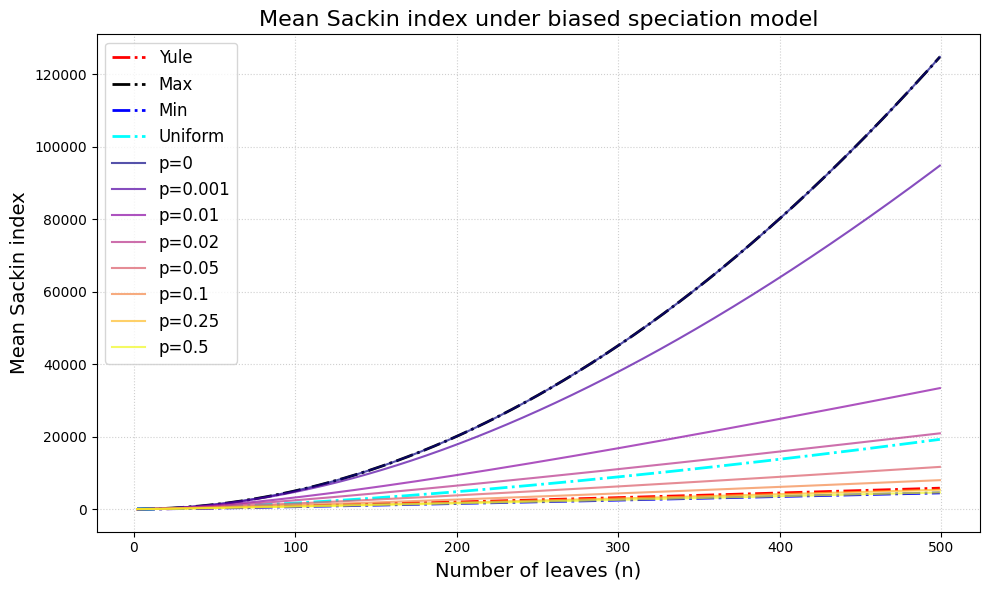

In [18]:
plt.figure(figsize=(10, 6))

# Data range
N = range(2, 500)


# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Values of p to plot
p = [0, 0.001, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5]

# Use a colormap for probabilities
# what is best colormap? not viridis
colors = cm.plasma(np.linspace(0, 1, len(p)))

for prob, color in zip(p, colors):
    means = [sackin_mean_const_p(n, prob) for n in N]
    plt.plot(N, means, label=f"p={prob}", alpha=0.7, color=color, lw=1.5)


# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)


# Legend only for reference lines
plt.legend(fontsize=12, loc="upper left")

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

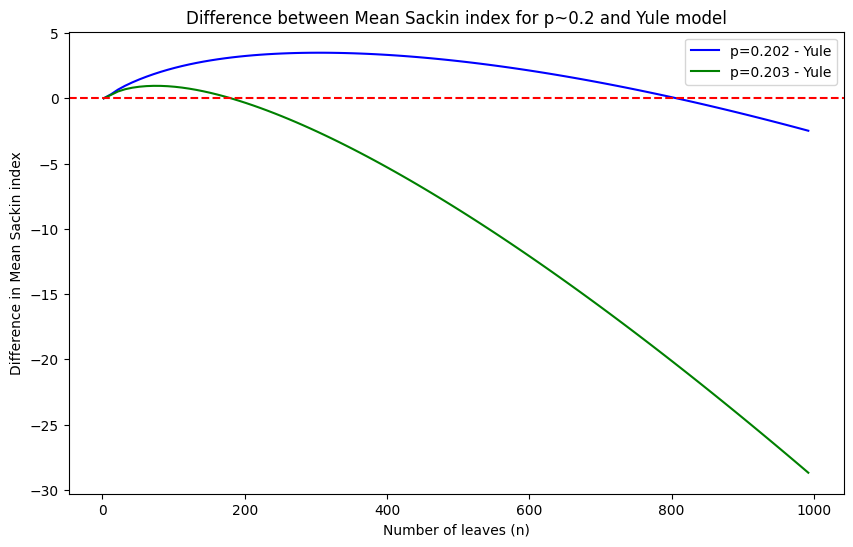

In [19]:
# Comparing the p=0.2 case to Yule

s1 = 0.202
s2 = 0.203
N = np.arange(2, 1000, 10)

diff = [sackin_mean_const_p(n, s1) - sackin_yule(n) for n in N]
diff2 = [sackin_mean_const_p(n, s2) - sackin_yule(n) for n in N]
plt.figure(figsize=(10, 6))
plt.plot(N, diff, label=f"p={s1} - Yule", color='blue')
plt.plot(N, diff2, label=f"p={s2} - Yule", color='green')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Difference in Mean Sackin index")
plt.title("Difference between Mean Sackin index for p~0.2 and Yule model")
plt.legend()
plt.show()

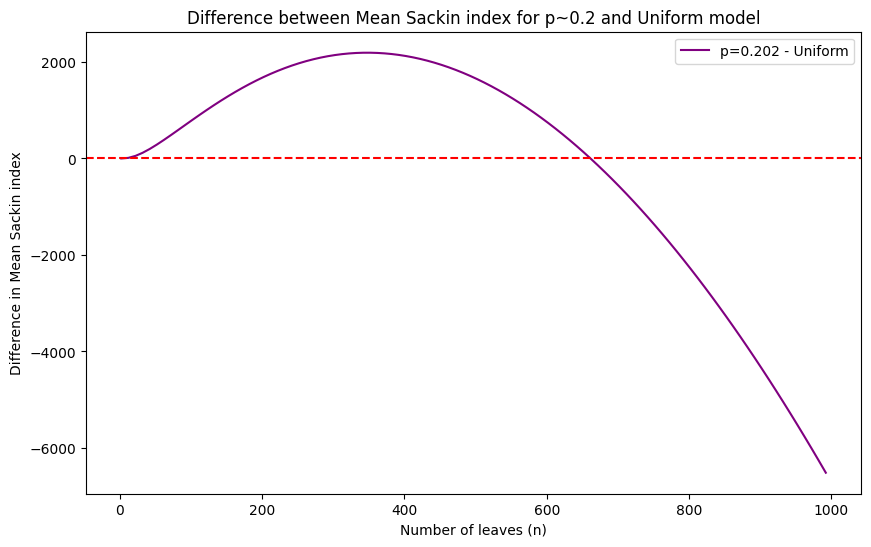

In [20]:
# Do same for Uniform model
s = 0.02
diff = [sackin_mean_const_p(n, s) - sackin_uniform(n) for n in N]
plt.figure(figsize=(10, 6))
plt.plot(N, diff, label=f"p={s1} - Uniform", color='purple')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Difference in Mean Sackin index")
plt.title("Difference between Mean Sackin index for p~0.2 and Uniform model")
plt.legend()
plt.show()

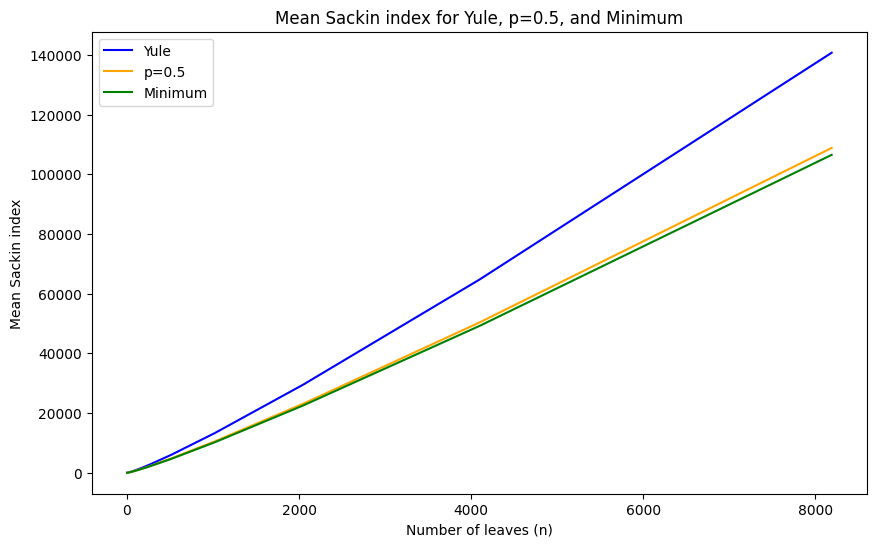

In [84]:
N = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

yule = [sackin_yule(n) for n in N]
p05 = [sackin_mean_const_p_stable(n, 0.5, digits= max(40, n//2)) for n in N]
minimum = [min_sackin(n) for n in N]

plt.figure(figsize=(10, 6))
plt.plot(N, yule, label="Yule", color='blue')  
plt.plot(N, p05, label="p=0.5", color='orange')
plt.plot(N, minimum, label="Minimum", color='green')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Mean Sackin index")
plt.title("Mean Sackin index for Yule, p=0.5, and Minimum")
plt.legend()
plt.show()

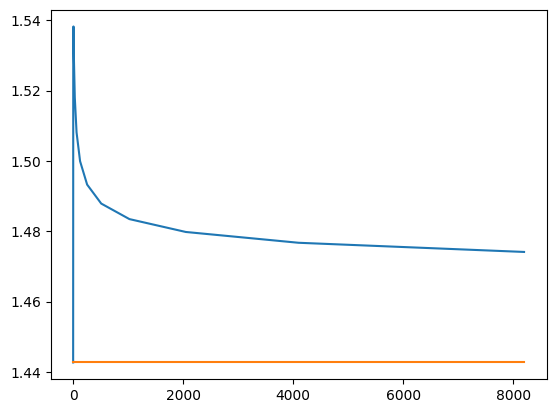

In [89]:
vals = np.array(p05)

plt.plot(N, vals/ np.log(np.array(N)) / np.array(N))
plt.plot(N, minimum/ np.log(np.array(N)) / np.array(N))

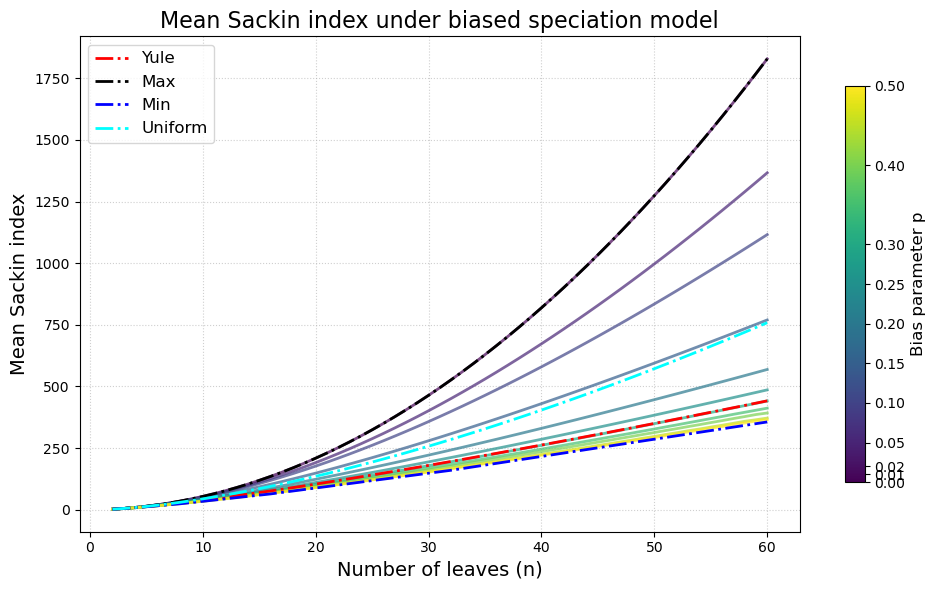

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

plt.figure(figsize=(10, 6))

p = [0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
N = np.arange(2, 61)

# Use a colormap for probabilities
colors = cm.viridis(np.linspace(0, 1, len(p)))

for prob, color in zip(p, colors):
    means = [sackin_constant_p(n, prob) for n in N]
    plt.plot(N, means, color=color, alpha=0.7, lw=2)

# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)

# Colorbar for p values
sm = cm.ScalarMappable(cmap=cm.viridis, 
                       norm=plt.Normalize(vmin=min(p), vmax=max(p)))
sm.set_array([])
cbar = plt.colorbar(sm, ticks=p, shrink=0.8, ax=plt.gca())
cbar.set_label("Bias parameter p", fontsize=12)

# Legend only for reference lines
plt.legend(fontsize=12, loc="upper left")

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

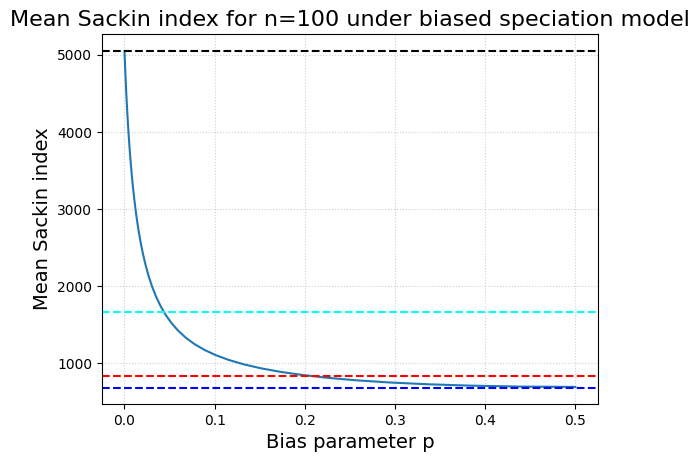

In [59]:
# Fix n, find mean for a range of p
p = np.logspace(-20, -1, 100, base=2)

n = 100
plt.plot(p, [sackin_mean_const_p(n, prob) for prob in p])

# Add horizontal lines for reference models
plt.axhline(sackin_yule(n), color='red', linestyle='--', label="Yule")
plt.axhline(sackin_uniform(n), color='aqua', linestyle='--', label="Uniform")
plt.axhline(max_sackin(n), color='black', linestyle='--', label="Max")
plt.axhline(min_sackin(n), color='blue', linestyle='--', label  ="Min")

plt.xlabel("Bias parameter p", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title(f"Mean Sackin index for n={n} under biased speciation model", fontsize=16)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

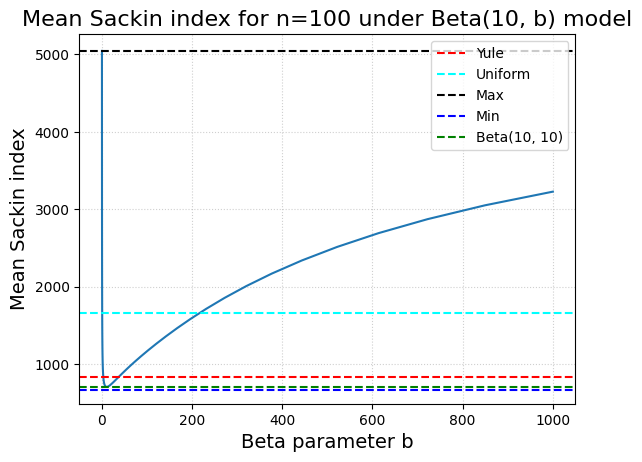

In [69]:
# Do same with beta(1, b) model
a = 10
b = np.logspace(-5, 2, 100, base=10) * a

n = 100
plt.plot(b, [sackin_mean_beta(n, a, bi) for bi in b])

# Add horizontal lines for reference models
plt.axhline(sackin_yule(n), color='red', linestyle='--', label="Yule")
plt.axhline(sackin_uniform(n), color='aqua', linestyle='--', label="Uniform")
plt.axhline(max_sackin(n), color='black', linestyle='--', label="Max")
plt.axhline(min_sackin(n), color='blue', linestyle='--', label  ="Min")

# Also add beta(a,a) line for comparison
plt.axhline(sackin_mean_beta(n, a, a), color='green', linestyle='--', label=f"Beta({a}, {a})")

plt.xlabel("Beta parameter b", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title(f"Mean Sackin index for n={n} under Beta({a}, b) model", fontsize=16)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

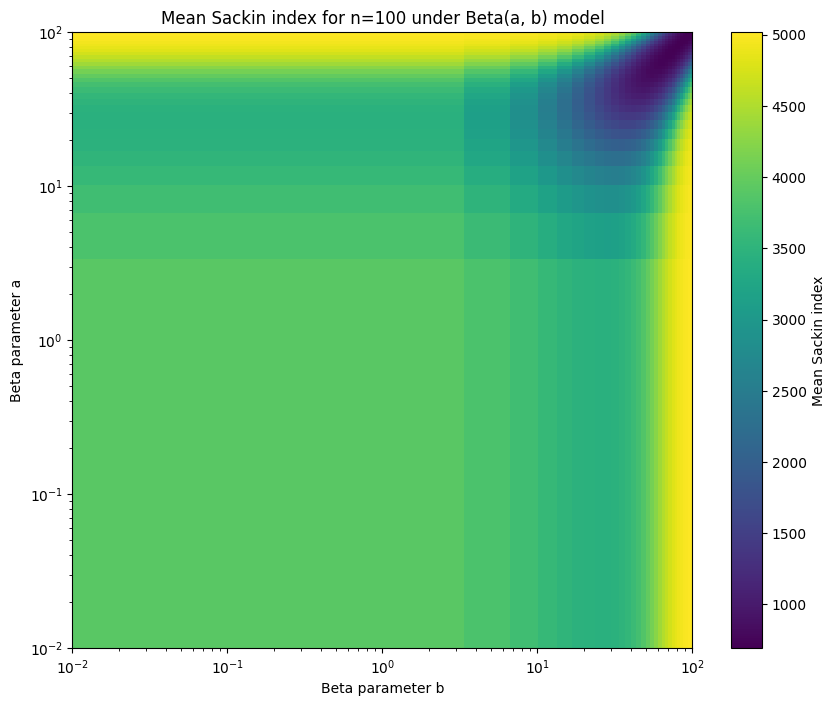

In [76]:
a = np.logspace(-2, 2, 30, base=10)
b = a
n = 100

mean_sackin = np.zeros((len(a), len(b)))
for i, ai in enumerate(a):
    for j, bi in enumerate(b):
        mean_sackin[i, j] = sackin_mean_beta(n, ai, bi)

# Plot this as a heatmap
plt.figure(figsize=(10, 8))
plt.imshow(mean_sackin, extent=(min(b), max(b), min(a), max(a)), 
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Sackin index')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Beta parameter b')
plt.ylabel('Beta parameter a')
plt.title(f'Mean Sackin index for n={n} under Beta(a, b) model')
plt.show()

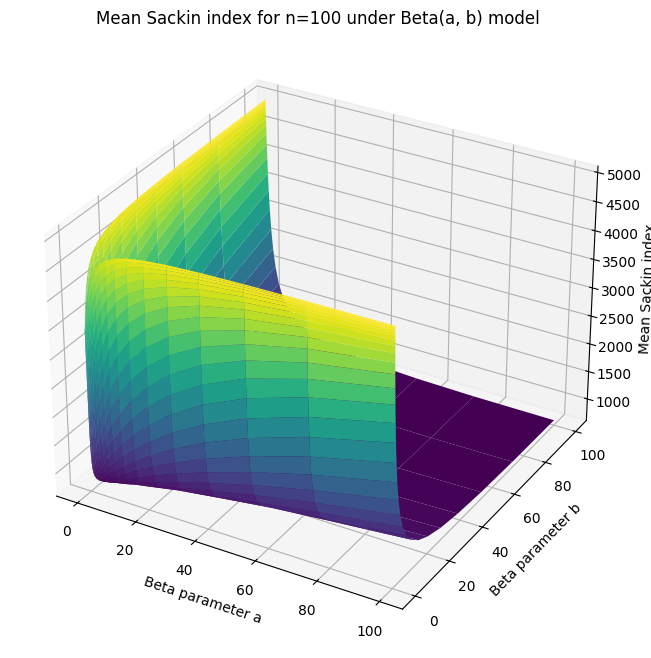

In [78]:
# Plot mean_sackin as a function of (a,b) in a 3D surface plot

from mpl_toolkits.mplot3d import Axes3D

plt.figure(figsize=(12, 8))
ax = plt.axes(projection='3d')
A, B = np.meshgrid(a, b)
ax.plot_surface(A, B, mean_sackin.T, cmap='viridis')
ax.set_xlabel('Beta parameter a')
ax.set_ylabel('Beta parameter b')
ax.set_zlabel('Mean Sackin index')
plt.title(f'Mean Sackin index for n={n} under Beta(a, b) model')
plt.show()

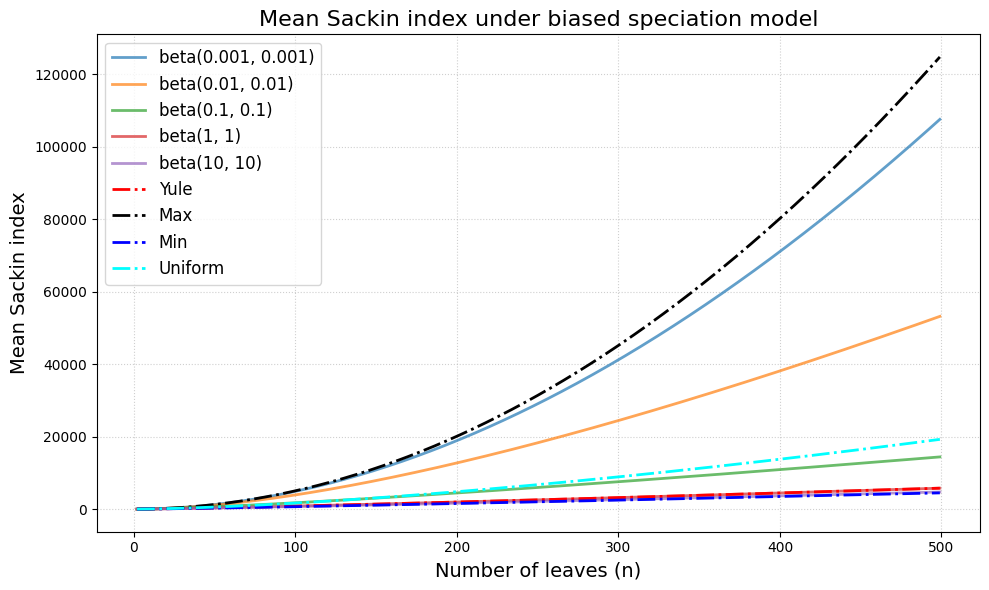

In [45]:
# Now make analogous plot for Beta(a,a) - Blum Francois model
a = [0.001, 0.01, 0.1, 1, 10]

N = np.arange(2, 500)

plt.figure(figsize=(10, 6))

colors = cm.viridis(np.linspace(0, 1, len(a)))

for (color, ai) in zip(colors, a):
    means = [sackin_mean_beta(n, ai, ai) for n in N]
    plt.plot(N, means, alpha=0.7, lw=2, label=f"beta({ai}, {ai})")

# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)
plt.legend(fontsize=12, loc="upper left")


# Grid and layout

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

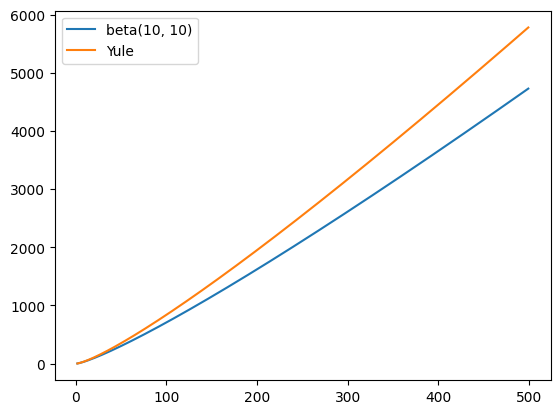

In [47]:
plt.plot(N, means, label=f"beta({ai}, {ai})")
plt.plot(N, [sackin_yule(n) for n in N], label="Yule")
plt.legend()
plt.show()

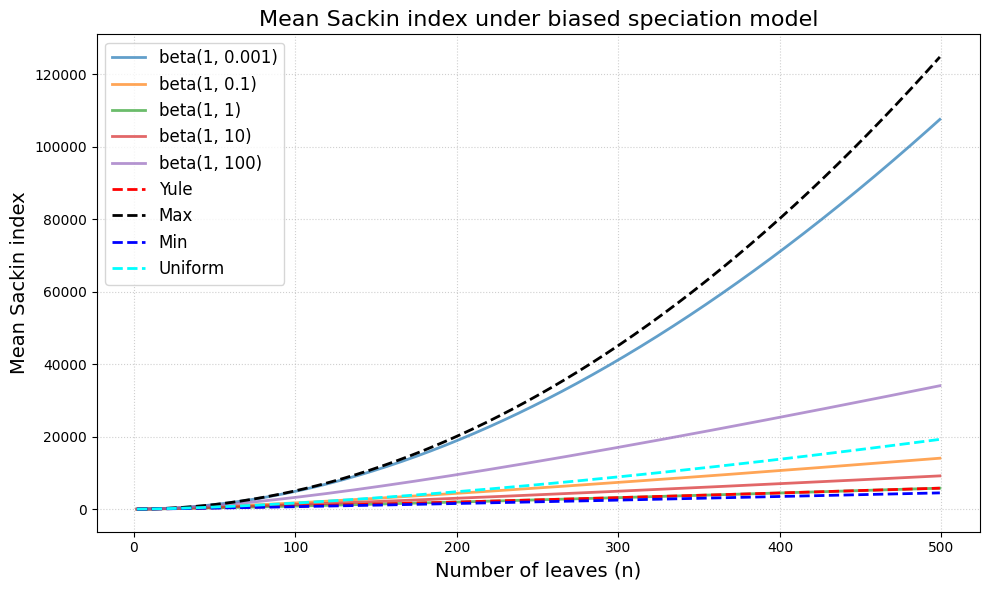

In [48]:
a = 1
b = [0.001, 0.1, 1, 10, 100]

plt.figure(figsize=(10, 6))

for bi in b:
    means = [sackin_mean_beta(n, a, bi) for n in N]
    plt.plot(N, means, alpha=0.7, lw=2, label=f"beta({a}, {bi})")
# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], linestyle='dashed', color='red', label="Yule", linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], linestyle='dashed', color='black', label="Max", linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], linestyle='dashed', color='blue', label="Min", linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], linestyle='dashed', color='aqua', label="Uniform", linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)
plt.legend(fontsize=12, loc="upper left")
# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

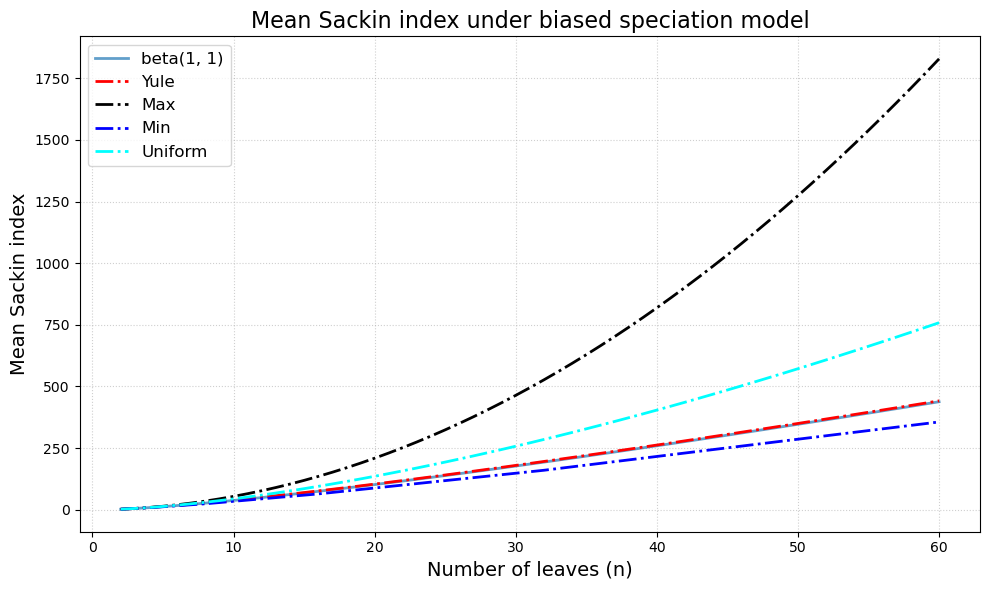

In [5]:
# Just do a = b = 1
plt.figure(figsize=(10, 6))
means = [sackin_beta(n, 1, 1) for n in N]
plt.plot(N, means, alpha=0.7, lw=2, label=f"beta(1, 1)")


# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)
plt.legend(fontsize=12, loc="upper left")


# Grid and layout

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()